# Rational Quadratic Spline Flow: Bijection and Density Visualisation

In [21]:
from pathlib import Path

import jax
import jax.nn as jnn
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from flax import nnx
from matplotlib.lines import Line2D
from tensorflow_probability.substrates.jax import distributions

from confrdm_jax.flows import load_conditioner, make_mlp_conditioner, spline_flow

jax.config.update("jax_enable_x64", True)

In [22]:
rngs = nnx.Rngs(default=jax.random.key(2026))

NUM_BINS  = 12
NUM_MID   = 128
RANGE_MIN = -5.0
RANGE_MAX =  5.0

conditioner_path = (
    Path("../outputs/rdm").absolute()
    / f"model.num_bins={NUM_BINS}/model.num_mid={NUM_MID}"
    / "optimizer=adam_cosine_decay/train_steps=500000/conditioner"
)

conditioner = load_conditioner(
    make_mlp_conditioner(num_in=3, num_bins=NUM_BINS, num_mid=NUM_MID, rngs=rngs),
    conditioner_path,
)
conditioner.eval()

In [23]:
Z_MIN, Z_MAX, NUM_Z = -5.5, 2, 1200
z_range = np.linspace(Z_MIN, Z_MAX, NUM_Z)
RT_MIN, RT_MAX = 1e-4, 4.0
rt_range = jnp.linspace(RT_MIN, RT_MAX, NUM_Z)

In [24]:
def get_knot_positions(v: float, s: float, b: float):
    """
    Recover spline knot positions from the raw conditioner output.

    The RQ-spline stores K bin widths (softmax-normalised) followed by
    K bin heights, giving K+1 knot positions in input (z) and output (y) space.
    After the exp bijector the output knots land at exp(y_knots) in RT space.
    """
    num_segments   = NUM_BINS
    total_range = RANGE_MAX - RANGE_MIN
    params  = conditioner(jnp.array([v, s, b]))
    widths  = jnn.softmax(params[:num_segments]) * total_range   # K values, sum = rng
    heights = jnn.softmax(params[num_segments:2*num_segments]) * total_range
    z_knots  = jnp.concatenate([jnp.array([RANGE_MIN]), RANGE_MIN + jnp.cumsum(widths)])
    y_knots  = jnp.concatenate([jnp.array([RANGE_MIN]), RANGE_MIN + jnp.cumsum(heights)])
    return np.asarray(z_knots), np.asarray(jnp.exp(y_knots))   # (K+1,), (K+1,)


def compute_densities(v: float, s: float, b: float):
    base = distributions.Normal(loc=0.0, scale=1.0)
    lp_z = base.log_prob(z_range)
    mu = b / v
    
    lp_rt, _ = spline_flow(rt_range, jnp.array([v, s, b]), conditioner)
    lam = (b / s) ** 2
    lp_wald = distributions.InverseGaussian(mu, lam).log_prob(rt_range)
    return (
        np.exp(np.asarray(lp_z)), np.exp(np.asarray(lp_rt)), np.exp(np.asarray(lp_wald)),
    )

In [25]:
param_sets = [
    dict(v=1.0, s=1.0, b=1.5, label=r"$\nu{=}1,\;\sigma{=}1,\;b{=}1.5$", color="#1b9e77"),
    dict(v=1.5, s=1.0, b=1.5, label=r"$\nu{=}1.5,\;\sigma{=}1.0,\;b{=}1.5$", color="#d95f02"),
    dict(v=2.5, s=1.0, b=1.5, label=r"$\nu{=}2.5,\;\sigma{=}1.0,\;b{=}1.5$", color="#7570b3"),
]

results = [compute_densities(p["v"], p["s"], p["b"]) for p in param_sets]

In [26]:
# Bijection curves and knot positions for all RDM parameter sets
bij_data_rdm = []
for ps in param_sets:
    _, flow_ps = spline_flow(rt_range, np.array([ps["v"], ps["s"], ps["b"]]), conditioner)
    rt_bij_ps = np.log(np.asarray(flow_ps.bijector.forward(jnp.array(z_range))))
    z_k, rt_k = get_knot_positions(ps["v"], ps["s"], ps["b"])
    bij_data_rdm.append(dict(rt_bij=rt_bij_ps, z_knots=z_k, rt_knots=rt_k))

---
## Conflict Racing Diffusion Model (CRDM)

Same figure for the CRDM conditioner (5 parameters: $v_c$, amp, $\tau$, $s$, $b$).
No analytical density equivalent exists — only the learned flow is shown.

In [27]:
conditioner_crdm_path = (
    Path("../outputs/crdm").absolute()
    / f"model.num_bins={NUM_BINS}/model.num_mid={NUM_MID}/model.sampler.dt=0.0005"
    / "optimizer=adam_cosine_decay/train_steps=1000000/conditioner"
)

conditioner_crdm = load_conditioner(
    make_mlp_conditioner(num_in=5, num_bins=NUM_BINS, num_mid=NUM_MID, rngs=rngs),
    conditioner_crdm_path,
)
conditioner_crdm.eval()

In [28]:
def get_knot_positions_crdm(v_c: float, amp: float, tau: float, s: float, b: float):
    K   = NUM_BINS
    rng = RANGE_MAX - RANGE_MIN
    params  = conditioner_crdm(jnp.array([v_c, amp, tau, s, b]))
    widths  = jnn.softmax(params[:K]) * rng
    heights = jnn.softmax(params[K:2*K]) * rng
    z_knots = jnp.concatenate([jnp.array([RANGE_MIN]), RANGE_MIN + jnp.cumsum(widths)])
    y_knots = jnp.concatenate([jnp.array([RANGE_MIN]), RANGE_MIN + jnp.cumsum(heights)])
    return np.asarray(z_knots), np.asarray(jnp.exp(y_knots))   # (K+1,), (K+1,)


def compute_densities_crdm(v_c: float, amp: float, tau: float, s: float, b: float):
    """Return (p_z, p_flow) — no analytical equivalent for CRDM."""
    base  = distributions.Normal(loc=0.0, scale=1.0)
    lp_z  = base.log_prob(z_range)
    lp_rt, _ = spline_flow(rt_range, jnp.array([v_c, amp, tau, s, b]), conditioner_crdm)
    return np.exp(np.asarray(lp_z)), np.exp(np.asarray(lp_rt))


# Parameter sets: values near the informed prior means with variation in v_c / amp / tau
param_sets_crdm = [
    dict(v_c=4.0, amp=0.20, tau=0.10, s=0.8, b=0.9,
         label=r"$\zeta{=}0.20,\ \tau{=}0.10$", color="#1b9e77"),
    dict(v_c=4.0, amp=0.30, tau=0.15, s=0.8, b=0.9,
         label=r"$\zeta{=}0.30,\ \tau{=}0.15$", color="#d95f02"),
    dict(v_c=4.0, amp=0.40, tau=0.08, s=0.8, b=0.9,
         label=r"$\zeta{=}0.40,\ \tau{=}0.05$", color="#7570b3"),
]

results_crdm = [
    compute_densities_crdm(p["v_c"], p["amp"], p["tau"], p["s"], p["b"])
    for p in param_sets_crdm
]

# Bijection curves and knot positions for all CRDM parameter sets
bij_data_crdm = []
for ps in param_sets_crdm:
    _, flow_ps = spline_flow(
        rt_range,
        jnp.array([ps["v_c"], ps["amp"], ps["tau"], ps["s"], ps["b"]]),
        conditioner_crdm,
    )
    rt_bij_ps = np.log(np.asarray(flow_ps.bijector.forward(jnp.array(z_range))))
    z_k, rt_k = get_knot_positions_crdm(ps["v_c"], ps["amp"], ps["tau"], ps["s"], ps["b"])
    bij_data_crdm.append(dict(rt_bij=rt_bij_ps, z_knots=z_k, rt_knots=rt_k))

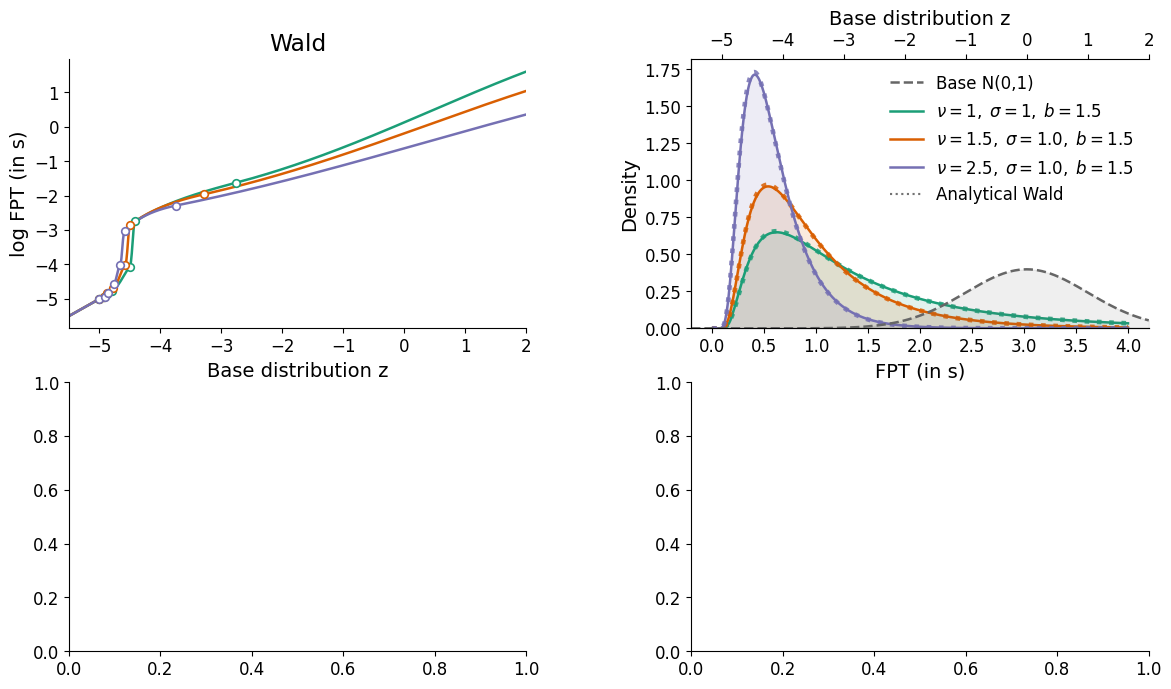

In [29]:
plt.rcParams.update({
    "font.family":         "sans-serif",
    "font.size":           14,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.labelsize":      14,
    "legend.fontsize":     12,
    "xtick.labelsize":     12,
    "ytick.labelsize":     12,
})

LW          = 1.8
ALPHA_FILL  = 0.13
XLIM_BIJ    = (Z_MIN, Z_MAX)

fig, ((ax_bij_rdm, ax_dens_rdm), (ax_bij_crdm, ax_dens_crdm)) = plt.subplots(2, 2, figsize=(12, 8))
fig.subplots_adjust(left=0.07, right=0.97, bottom=0.14, top=0.88, wspace=0.36)

for ps, bd in zip(param_sets, bij_data_rdm):
    vis = (bd["z_knots"] >= XLIM_BIJ[0]) & (bd["z_knots"] <= XLIM_BIJ[1])
    ax_bij_rdm.plot(z_range, bd["rt_bij"], color=ps["color"], lw=LW, label=ps["label"])
    ax_bij_rdm.scatter(
        bd["z_knots"][vis], np.log(bd["rt_knots"][vis]),
        color="white", edgecolors=ps["color"], linewidths=1.2,
        s=30, zorder=6,
    )

ax_bij_rdm.set_xlim(*XLIM_BIJ)
ax_bij_rdm.set_xlabel("Base distribution z")
ax_bij_rdm.set_ylabel("log FPT (in s)")
ax_bij_rdm.set_title("Wald")

ax_z = ax_dens_rdm.twiny()

lp_z = results[0][0]
ax_z.plot(z_range, lp_z, color="0.40", lw=LW, ls="--",
          label="Base N(0,1)")
ax_z.fill_between(z_range, lp_z, alpha=0.10, color="0.40")
ax_z.set_xlim(Z_MIN, Z_MAX)
ax_z.set_xlabel("Base distribution z", labelpad=5)
ax_z.spines["top"].set_visible(True)

for ps, (_, p_flow, lp_wald) in zip(param_sets, results):
    ax_dens_rdm.plot(rt_range, p_flow, color=ps["color"], lw=LW, label=ps["label"])
    ax_dens_rdm.plot(rt_range, lp_wald, color=ps["color"], lw=LW * 1.85,
                 ls=":", alpha=0.85, label="_nolegend_")
    ax_dens_rdm.fill_between(rt_range, p_flow, alpha=ALPHA_FILL, color=ps["color"])

ax_dens_rdm.set_ylim(bottom=0)
ax_dens_rdm.set_xlabel("FPT (in s)")
ax_dens_rdm.set_ylabel("Density")

base_handles, base_labels = ax_z.get_legend_handles_labels()
flow_handles, flow_labels = ax_dens_rdm.get_legend_handles_labels()
wald_proxy = Line2D([0], [0], color="0.45", lw=LW * 0.85, ls=":")
ax_dens_rdm.legend(
    base_handles + flow_handles + [wald_proxy],
    base_labels + flow_labels + ["Analytical Wald"],
    loc="upper right", frameon=False,
);

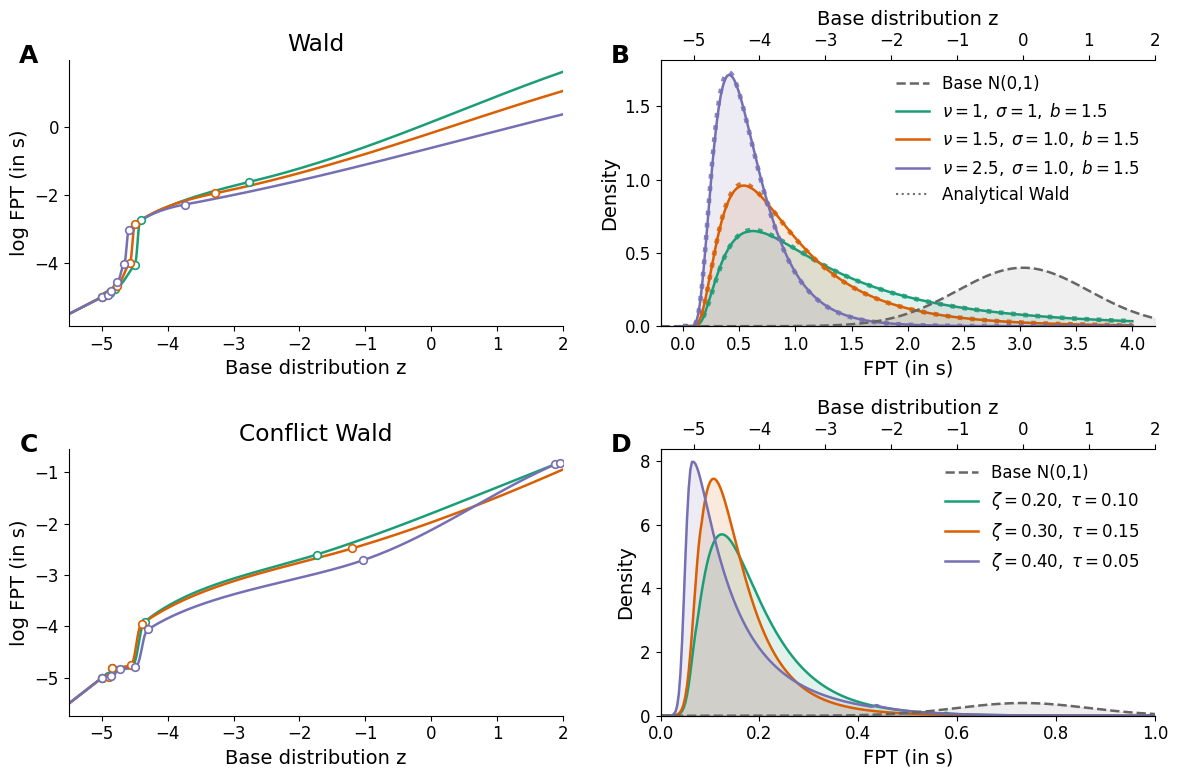

In [30]:
# ── CRDM bijection: one curve + knots per parameter set ───────────────────────
for ps, bd in zip(param_sets_crdm, bij_data_crdm):
    vis = (bd["z_knots"] >= XLIM_BIJ[0]) & (bd["z_knots"] <= XLIM_BIJ[1])
    ax_bij_crdm.plot(z_range, bd["rt_bij"], color=ps["color"], lw=LW, label=ps["label"])
    ax_bij_crdm.scatter(
        bd["z_knots"][vis], np.log(bd["rt_knots"][vis]),
        color="white", edgecolors=ps["color"], linewidths=1.2,
        s=30, zorder=6,
    )

ax_bij_crdm.set_xlim(*XLIM_BIJ)
ax_bij_crdm.set_xlabel("Base distribution z")
ax_bij_crdm.set_ylabel("log FPT (in s)")
ax_bij_crdm.set_title("Conflict Wald")
ax_z_crdm = ax_dens_crdm.twiny()

lp_z_crdm = results_crdm[0][0]
ax_z_crdm.plot(z_range, lp_z_crdm, color="0.40", lw=LW, ls="--", label="Base N(0,1)")
ax_z_crdm.fill_between(z_range, lp_z_crdm, alpha=0.10, color="0.40")
ax_z_crdm.set_xlim(Z_MIN, Z_MAX)
ax_z_crdm.set_xlabel("Base distribution z", labelpad=5)
ax_z_crdm.spines["top"].set_visible(True)

for ps, (_, p_flow_crdm) in zip(param_sets_crdm, results_crdm):
    ax_dens_crdm.plot(rt_range, p_flow_crdm, color=ps["color"], lw=LW, label=ps["label"])
    ax_dens_crdm.fill_between(rt_range, p_flow_crdm, alpha=ALPHA_FILL, color=ps["color"])

ax_dens_crdm.set_ylim(bottom=0)
ax_dens_crdm.set_xlim(0, 1.0)
ax_dens_crdm.set_xlabel("FPT (in s)")
ax_dens_crdm.set_ylabel("Density")

base_handles, base_labels = ax_z_crdm.get_legend_handles_labels()
flow_handles, flow_labels = ax_dens_crdm.get_legend_handles_labels()
ax_dens_crdm.legend(
    base_handles + flow_handles,
    base_labels + flow_labels,
    loc="upper right", frameon=False,
)

for ax, letter in zip([ax_bij_rdm, ax_dens_rdm, ax_bij_crdm, ax_dens_crdm], "ABCD"):
    ax.text(-0.10, 1.06, letter, transform=ax.transAxes,
            fontsize=18, fontweight="bold", va="top")

fig.tight_layout()

fig.savefig("spline_flow_transformation.png", dpi=200, bbox_inches="tight")
fig